# SHAP Explainability Analysis for the BiLSTM Model

## Data Preparation and SHAP Value Computation

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import load_model
from pathlib import Path
import yaml

# --- Load configuration ---
project_root = Path(__file__).resolve().parent.parent
config_path = project_root / "config" / "config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# --- Optimized parameters ---
n_steps = 50  # Number of time steps in each sequence
feature_names = ['month', 'DV_pressure', 'day', 'Reservoirs', 'hour', 'minute', 'Motor_current', 'H1']
n_samples_fast = 1500  # Reduced number of test samples for faster computation
background_size = 50   # Smaller background set size for SHAP explainer

# --- Load test data and trained model ---
X_test_seq = joblib.load(project_root / "data" / "processed" / config["paths"]["processed"]["X_test_bilstm"])  # Shape: [samples, time steps, features]
model = load_model(project_root / config["paths"]["models"]["bilstm_model"])

# --- Random subsampling for SHAP explanation ---
np.random.seed(42)  # Ensure reproducibility
indices = np.random.choice(len(X_test_seq), n_samples_fast, replace=False)
X_test_fast = X_test_seq[indices]

# --- Create a small background set for SHAP ---
background_samples = X_test_seq[np.random.choice(len(X_test_seq), background_size, replace=False)]

# --- Initialize SHAP DeepExplainer ---
explainer = shap.DeepExplainer(model, background_samples)

# --- Compute SHAP values for the selected test subset ---
shap_values = explainer.shap_values(X_test_fast)  # Result shape: (1, n_samples_fast, n_steps, n_features)

# --- Temporal reduction: average SHAP values across time steps ---
shap_values_2d = np.mean(shap_values[0], axis=1)  # Result shape: (n_samples_fast, n_features)
X_test_2d = np.mean(X_test_fast, axis=1)  # Also average input sequences for visualization

 ## SHAP Summary Bar Plot

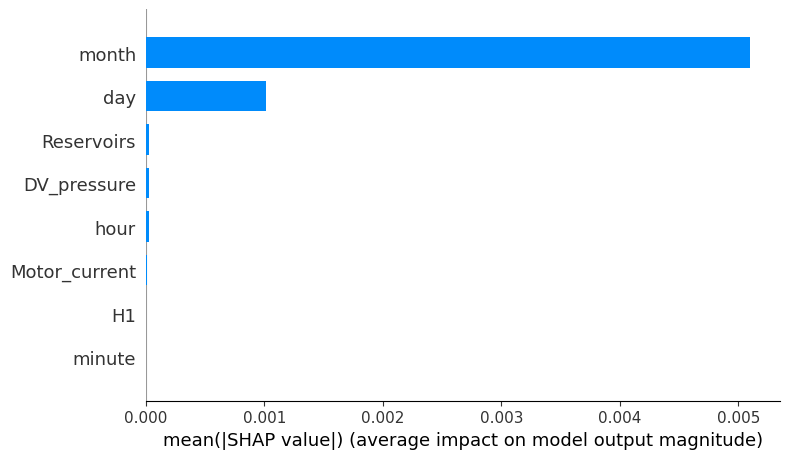

In [ ]:
shap.summary_plot(
    shap_values_2d,
    X_test_2d,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)
plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=300, bbox_inches='tight')
plt.close()

## SHAP Dependence Plots

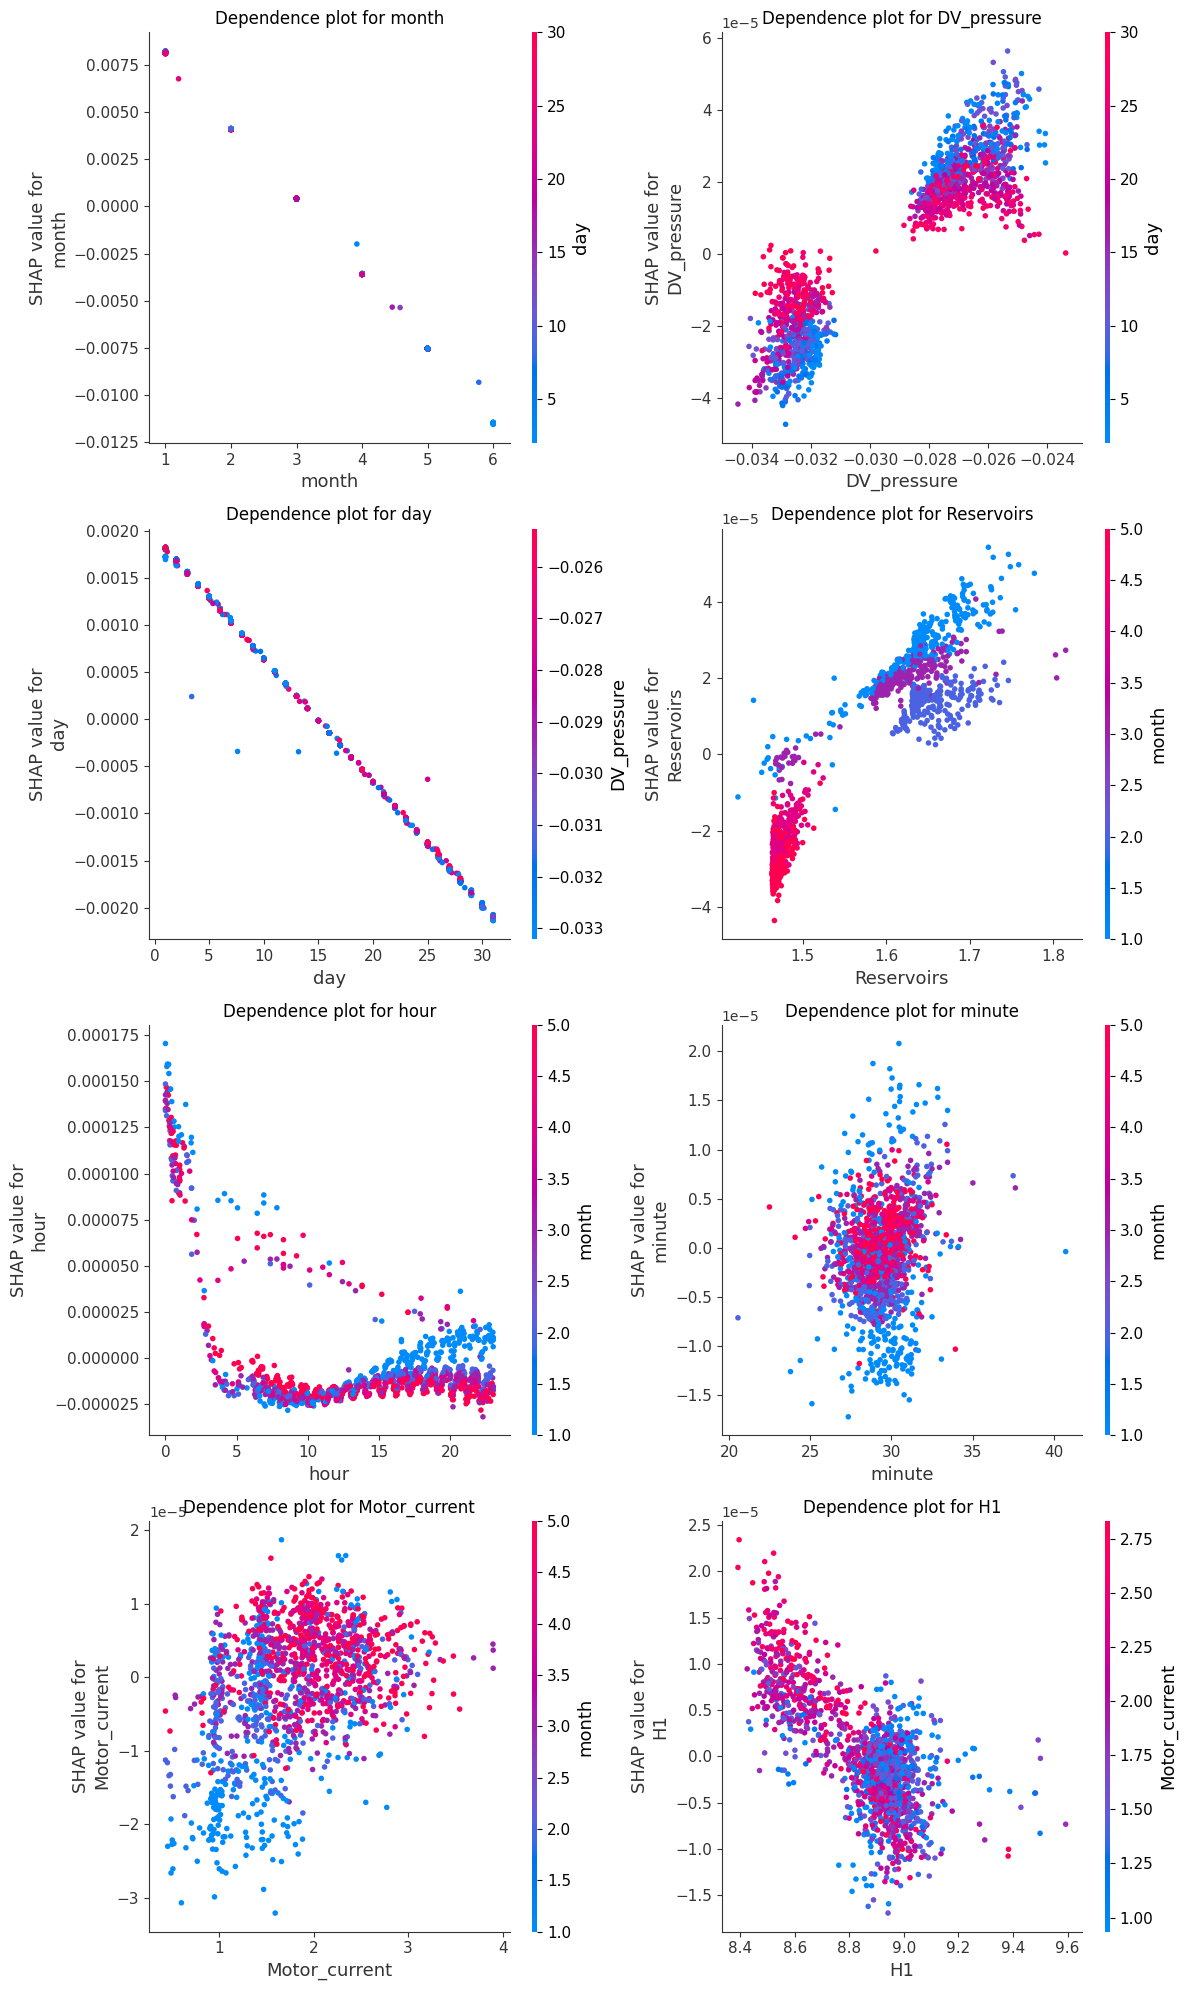

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
import yaml

# Load configuration
project_root = Path(__file__).resolve().parent.parent
config_path = project_root / "config" / "config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)


# Load scaler
scaler_X = joblib.load(project_root / "data" / "processed" / config["paths"]["processed"]["scaler_x_bilstm"])
X_test_denormalized = scaler_X.inverse_transform(X_test_2d)  # Dénormalisation des features

# Définir le nombre de lignes et de colonnes pour la mise en page
n_features = len(feature_names)
n_cols = 2  # Par exemple, 2 colonnes pour afficher les graphiques
n_rows = int(np.ceil(n_features / n_cols))  # Calculer le nombre de lignes nécessaires

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))

# Aplatir les axes pour une manipulation plus facile
axes = axes.flatten()

# Créer un graphique de dépendance pour chaque caractéristique
for i, feature_name in enumerate(feature_names):
    shap.dependence_plot(
        i,  # Index de la caractéristique
        shap_values_2d,  # Valeurs SHAP moyennées
        X_test_denormalized,  # Données d'entrée moyennées
        feature_names=feature_names,
        show=False,
        ax=axes[i]  # Associer chaque graphique à un axe spécifique
    )
    axes[i].set_title(f'Dependence plot for {feature_name}')  # Titre pour chaque sous-graphe

# Supprimer les axes vides si le nombre de caractéristiques n'est pas un multiple de n_cols
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

# Ajuster la disposition
plt.tight_layout()
# Sauvegarder la figure
plt.savefig("shap_dependence_color_all.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## SHAP Summary Dot Plot

### SHAP Summary Dot Plot for all features

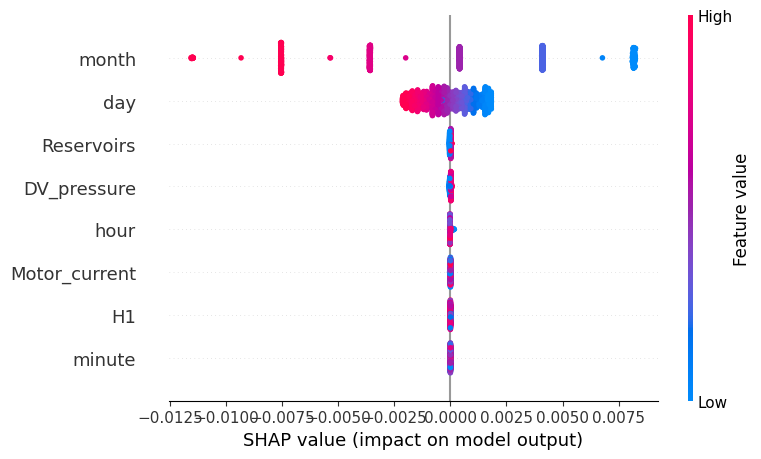

In [ ]:
shap.summary_plot(
    shap_values_2d,
    X_test_2d,
    feature_names=feature_names,
    plot_type="dot",
    show=True
)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')
plt.close()

### summary plot for sensors and tomporel

In [ ]:

sensor_features = ['DV_pressure', 'Reservoirs', 'Motor_current', 'H1']
temporal_features = ['month', 'day', 'hour', 'minute']

sensor_indices = [feature_names.index(f) for f in sensor_features]
temporal_indices = [feature_names.index(f) for f in temporal_features]

shap_sensor = shap_values_2d[:, sensor_indices]
X_sensor = X_test_2d[:, sensor_indices]

shap_temporal = shap_values_2d[:, temporal_indices]
X_temporal = X_test_2d[:, temporal_indices]


#### summary plot for sensors features

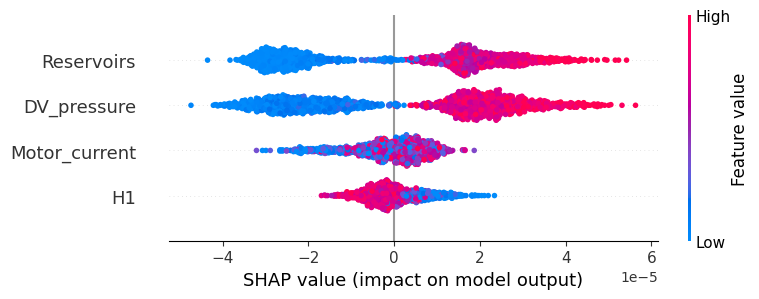

In [ ]:

shap.summary_plot(
    shap_sensor, X_sensor,
    feature_names=sensor_features,
    plot_type="dot",
    show=True
)
plt.tight_layout()
plt.savefig("shap_summary_sensors.png", dpi=300)
plt.close()




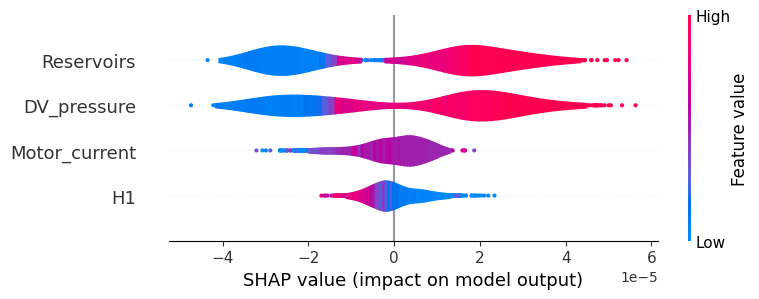

In [ ]:

shap.summary_plot(
    shap_sensor, X_sensor,
    feature_names=sensor_features,
    plot_type="violin",
    show=True
)
plt.tight_layout()
plt.savefig("shap_summary_sensors.png", dpi=300)
plt.close()




#### summary plot for temporal features

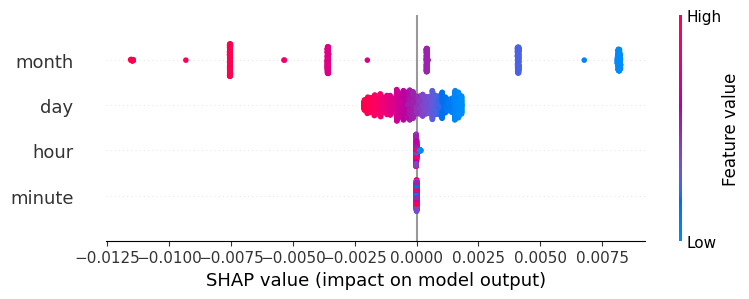

In [ ]:

shap.summary_plot(
    shap_temporal, X_temporal,
    feature_names=temporal_features,
    plot_type="dot",
    show=True
)
plt.tight_layout()
plt.savefig("shap_summary_temporal.png", dpi=300)
plt.close()

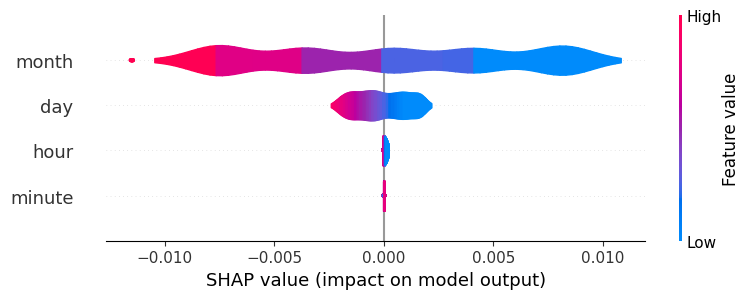

In [ ]:

shap.summary_plot(
    shap_temporal, X_temporal,
    feature_names=temporal_features,
    plot_type="violin",
    show=True
)
plt.tight_layout()
plt.savefig("shap_summary_temporal.png", dpi=300)
plt.close()